In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/concrete.csv")

In [ ]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
X=df.copy()
y = X.pop("strength")

In [ ]:
baseline = RandomForestRegressor(criterion="absolute_error", random_state = 0)
baseline_score = cross_val_score(baseline, X, y, cv = 5, scoring = "neg_mean_absolute_error")

baseline_score = -1 * baseline_score.mean()
print(f"MAE Baseline Score: {baseline_score}")

MAE Baseline Score: 8.231741796116504


<Axes: xlabel='None', ylabel='strength'>

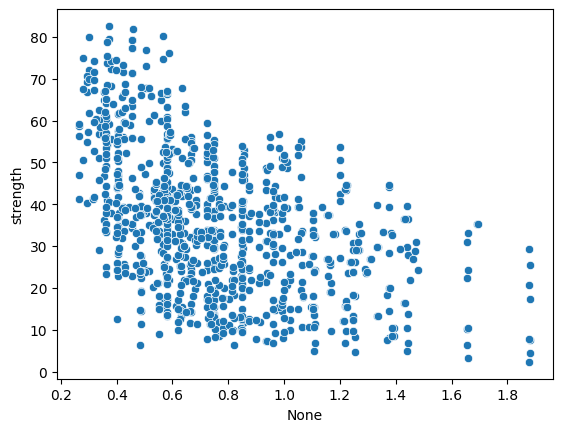

In [ ]:
import seaborn as sns
sns.scatterplot(x=df["water"]/df["cement"], y=df["strength"])

In [ ]:
X["WtrCmtRatio"] = X["water"] / X['cement']

In [ ]:
X.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,WtrCmtRatio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,0.300000
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,0.300000
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,0.685714
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,0.685714
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,0.966767


In [ ]:
model = RandomForestRegressor(criterion = "absolute_error", random_state = 0)
score = cross_val_score(model, X, y, cv = 5, scoring= "neg_mean_absolute_error")
score = -1*score.mean()
print(score)

7.931132087378638


In [ ]:
X["FCRatio"] = X["fineagg"]/X["coarseagg"]

In [ ]:
X.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,WtrCmtRatio,FCRatio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,0.300000,0.650000
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,0.300000,0.640758
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,0.685714,0.637339
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,0.685714,0.637339
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,0.966767,0.843724


In [ ]:
model2 = RandomForestRegressor(criterion = "absolute_error", random_state = 0)
score = cross_val_score(model2, X, y, cv = 5, scoring= "neg_mean_absolute_error")
score = -1*score.mean()
print(score)

8.039392718446601


In [ ]:
X.pop('FCRatio')

,FCRatio
0,0.650000
1,0.640758
2,0.637339
3,0.637339
4,0.843724
...,...
1025,0.883002
1026,0.994498
1027,0.874048
1028,0.797191


In [ ]:
X.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,WtrCmtRatio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,0.300000
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,0.300000
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,0.685714
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,0.685714
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,0.966767


In [ ]:
X["AggCmtRatio"] = (X["coarseagg"] + X["fineagg"])/ X["cement"]

In [ ]:
model3 = RandomForestRegressor(criterion = "absolute_error", random_state = 0)
score = cross_val_score(model3, X, y, cv = 5, scoring= "neg_mean_absolute_error")
score = -1*score.mean()
print(score)

7.840463155339803


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "autos.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ryanholbrook/fe-course-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_7959/3264283115.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 21.1k/21.1k [00:00<00:00, 34.0MB/s]

First 5 records:    symboling         make fuel_type aspiration  num_of_doors   body_style  \
0          3  alfa-romero       gas        std             2  convertible   
1          3  alfa-romero       gas        std             2  convertible   
2          1  alfa-romero       gas        std             2    hatchback   
3          2         audi       gas        std             4        sedan   
4          2         audi       gas        std             4        sedan   

  drive_wheels engine_location  wheel_base  length  ...  engine_size  \
0          rwd           front        88.6   168.8  ...          130   
1          rwd           front        88.6   168.8  ...          130   
2          rwd           front        94.5   171.2  ...          152   
3          fwd           front        99.8   176.6  ...          109   
4          4wd           front        99.4   176.6  ...          136   

   fuel_system  bore stroke  compression_ratio  horsepower peak_rpm  city_mpg  \
0     

In [ ]:
df.head()

,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,2,audi,gas,std,4,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,2,audi,gas,std,4,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


In [ ]:
df.columns

Index(['symboling', 'make', 'fuel_type', 'aspiration', 'num_of_doors',
       'body_style', 'drive_wheels', 'engine_location', 'wheel_base', 'length',
       'width', 'height', 'curb_weight', 'engine_type', 'num_of_cylinders',
       'engine_size', 'fuel_system', 'bore', 'stroke', 'compression_ratio',
       'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price'],
      dtype='object')

In [ ]:
X=df.copy()
y=X.pop("price")
for columnname in X.columns:
  if X[columnname].dtype == "object":
    X[columnname] = X[columnname].factorize()[0]

In [ ]:
X

,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,3,0,0,0,2,0,0,0,88.6,168.8,...,4,130,0,3.47,2.68,9,111,5000,21,27
1,3,0,0,0,2,0,0,0,88.6,168.8,...,4,130,0,3.47,2.68,9,111,5000,21,27
2,1,0,0,0,2,1,0,0,94.5,171.2,...,6,152,0,2.68,3.47,9,154,5000,19,26
3,2,1,0,0,4,2,1,0,99.8,176.6,...,4,109,0,3.19,3.40,10,102,5500,24,30
4,2,1,0,0,4,2,2,0,99.4,176.6,...,5,136,0,3.19,3.40,8,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,-1,20,0,0,4,2,0,0,109.1,188.8,...,4,141,0,3.78,3.15,9,114,5400,23,28
189,-1,20,0,1,4,2,0,0,109.1,188.8,...,4,141,0,3.78,3.15,8,160,5300,19,25
190,-1,20,0,0,4,2,0,0,109.1,188.8,...,6,173,0,3.58,2.87,8,134,5500,18,23
191,-1,20,1,1,4,2,0,0,109.1,188.8,...,6,145,5,3.01,3.40,23,106,4800,26,27


In [ ]:
model4 = RandomForestRegressor(criterion = "absolute_error", random_state = 0)
score = cross_val_score(model3, X, y, cv = 5, scoring= "neg_mean_absolute_error")
score = -1*score.mean()
print(score)

2392.7610593792174


# Mutual Information

In [ ]:
X.dtypes

,0
symboling,int64
make,int64
fuel_type,int64
aspiration,int64
num_of_doors,int64
body_style,int64
drive_wheels,int64
engine_location,int64
wheel_base,float64
length,float64


In [ ]:
discrete_features = X.dtypes == int
from sklearn.feature_selection import mutual_info_regression
def make_mi_scores(X, y, discrete_features):
  mi_scores = mutual_info_regression(X,y, discrete_features = discrete_features)
  mi_scores = pd.Series(mi_scores, name = "MI Scores", index = X.columns)
  mi_scores = mi_scores.sort_values(ascending = False)
  return mi_scores
mi_scores = make_mi_scores(X,y, discrete_features)
mi_scores


,MI Scores
curb_weight,1.536939
horsepower,1.253464
engine_size,0.996845
highway_mpg,0.949189
city_mpg,0.853056
width,0.686005
length,0.616243
wheel_base,0.590017
make,0.543721
fuel_system,0.482927


In [ ]:
top_features = mi_scores.head(9).index

In [ ]:
top_features

Index(['curb_weight', 'horsepower', 'engine_size', 'highway_mpg', 'city_mpg',
       'width', 'length', 'wheel_base', 'make'],
      dtype='object')

In [ ]:
X_selected = X[top_features]
model5 = RandomForestRegressor(criterion = "absolute_error", random_state = 0)
score = cross_val_score(model5, X_selected , y, cv = 5, scoring= "neg_mean_absolute_error")
score = -1*score.mean()
print(score)

2438.378512145749
